# 05: Model Comparison and Final Evaluation

**Author:** Karan Homayounfar (25065219), UWE Bristol

This notebook aggregates results from all models (Logistic Regression, Random Forest, XGBoost, SVM) and produces the report-ready comparison table, overlaid ROC/PR curves, McNemar statistical significance tests, and calibration curves.

In [1]:
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay, confusion_matrix
)
from statsmodels.stats.contingency_tables import mcnemar

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

DATA_DIR    = '../data/processed'
FIGURES_DIR = '../report/figures'
import os
os.makedirs(FIGURES_DIR, exist_ok=True)

In [2]:
X_train = np.load(f'{DATA_DIR}/X_train.npy')
X_test  = np.load(f'{DATA_DIR}/X_test.npy')
y_train = np.load(f'{DATA_DIR}/y_train.npy')
y_test  = np.load(f'{DATA_DIR}/y_test.npy')

lr_probs  = np.load(f'{DATA_DIR}/lr_test_probs.npy')
lr_preds  = np.load(f'{DATA_DIR}/lr_test_preds.npy')
rf_probs  = np.load(f'{DATA_DIR}/rf_test_probs.npy')
rf_preds  = np.load(f'{DATA_DIR}/rf_test_preds.npy')
xgb_probs = np.load(f'{DATA_DIR}/xgb_test_probs.npy')
xgb_preds = np.load(f'{DATA_DIR}/xgb_test_preds.npy')

with open(f'{DATA_DIR}/lr_metrics.pkl', 'rb') as f:  lr_m  = pickle.load(f)
with open(f'{DATA_DIR}/rf_metrics.pkl', 'rb') as f:  rf_m  = pickle.load(f)
with open(f'{DATA_DIR}/xgb_metrics.pkl', 'rb') as f: xgb_m = pickle.load(f)

print('All previously computed results loaded.')

All previously computed results loaded.


## 1. SVM (LinearSVC with probability calibration)

In [4]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {'estimator__C': [0.01, 0.1, 1]}

base_svm = CalibratedClassifierCV(
    LinearSVC(class_weight='balanced', max_iter=2000, random_state=42),
    cv=3, method='sigmoid'
)

svm_inner = GridSearchCV(
    base_svm,
    param_grid,
    cv=inner_cv,
    scoring='f1_macro',
    n_jobs=-1
)

outer_f1_svm  = []
outer_auc_svm = []
best_params_svm = []

print('Running nested CV for SVM (5 outer x 3 inner)...')
for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train), 1):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    svm_inner.fit(X_tr, y_tr)
    best_params_svm.append(svm_inner.best_params_)

    y_pred = svm_inner.predict(X_val)
    y_prob = svm_inner.predict_proba(X_val)[:, 1]

    f1  = f1_score(y_val, y_pred, average='macro')
    auc = roc_auc_score(y_val, y_prob)
    outer_f1_svm.append(f1)
    outer_auc_svm.append(auc)
    print(f'  Fold {fold}: F1-macro={f1:.4f}, ROC-AUC={auc:.4f} | {svm_inner.best_params_}')

print(f'\nNested CV F1-macro:  {np.mean(outer_f1_svm):.4f} +/- {np.std(outer_f1_svm):.4f}')
print(f'Nested CV ROC-AUC:  {np.mean(outer_auc_svm):.4f} +/- {np.std(outer_auc_svm):.4f}')

Running nested CV for SVM (5 outer x 3 inner)...
  Fold 1: F1-macro=0.8988, ROC-AUC=0.9778 | {'estimator__C': 1}
  Fold 2: F1-macro=0.8985, ROC-AUC=0.9778 | {'estimator__C': 1}
  Fold 3: F1-macro=0.8957, ROC-AUC=0.9770 | {'estimator__C': 0.1}
  Fold 4: F1-macro=0.8959, ROC-AUC=0.9771 | {'estimator__C': 1}
  Fold 5: F1-macro=0.8976, ROC-AUC=0.9775 | {'estimator__C': 1}

Nested CV F1-macro:  0.8973 +/- 0.0013
Nested CV ROC-AUC:  0.9775 +/- 0.0003


## 1b. Naive structural baseline (robustness check)

`RETROFIT_POTENTIAL` is derived from `gap = POTENTIAL_ENERGY_EFFICIENCY - CURRENT_ENERGY_EFFICIENCY`.
`POTENTIAL_ENERGY_EFFICIENCY` is never a feature, but `CURRENT_ENERGY_EFFICIENCY` is, and low current
efficiency mechanically leaves more room for a large gap (potential is capped near 100). This checks how
much of the four models' performance that structural relationship explains on its own, using only
`CURRENT_ENERGY_EFFICIENCY` and `CURRENT_ENERGY_RATING` in an otherwise identical LR setup. Diagnostic,
not a fifth model in the comparison.

In [5]:
with open(f'{DATA_DIR}/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

naive_cols = [feature_names.index('CURRENT_ENERGY_EFFICIENCY'), feature_names.index('CURRENT_ENERGY_RATING')]
X_train_naive = X_train[:, naive_cols]
X_test_naive  = X_test[:, naive_cols]

naive_inner = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs', random_state=42),
    {'C': [0.01, 0.1, 1, 10, 100]},
    cv=inner_cv, scoring='f1_macro', n_jobs=-1
)

naive_outer_f1, naive_outer_auc, naive_best_Cs = [], [], []
for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X_train_naive, y_train), 1):
    X_tr, X_val = X_train_naive[train_idx], X_train_naive[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]

    naive_inner.fit(X_tr, y_tr)
    naive_best_Cs.append(naive_inner.best_params_['C'])

    y_pred = naive_inner.predict(X_val)
    y_prob = naive_inner.predict_proba(X_val)[:, 1]
    naive_outer_f1.append(f1_score(y_val, y_pred, average='macro'))
    naive_outer_auc.append(roc_auc_score(y_val, y_prob))
    print(f'  Fold {fold}: F1-macro={naive_outer_f1[-1]:.4f}, ROC-AUC={naive_outer_auc[-1]:.4f}')

print(f'\nNaive baseline nested CV F1-macro: {np.mean(naive_outer_f1):.4f} +/- {np.std(naive_outer_f1):.4f}')
print(f'Naive baseline nested CV ROC-AUC:  {np.mean(naive_outer_auc):.4f} +/- {np.std(naive_outer_auc):.4f}')

  Fold 1: F1-macro=0.8193, ROC-AUC=0.9493
  Fold 2: F1-macro=0.8204, ROC-AUC=0.9503
  Fold 3: F1-macro=0.8217, ROC-AUC=0.9493
  Fold 4: F1-macro=0.8208, ROC-AUC=0.9485
  Fold 5: F1-macro=0.8238, ROC-AUC=0.9505

Naive baseline nested CV F1-macro: 0.8212 +/- 0.0015
Naive baseline nested CV ROC-AUC:  0.9496 +/- 0.0007


In [6]:
naive_best_C = max(set(naive_best_Cs), key=naive_best_Cs.count)

naive_final = LogisticRegression(C=naive_best_C, class_weight='balanced', max_iter=1000,
                                  solver='lbfgs', random_state=42)
naive_final.fit(X_train_naive, y_train)

naive_pred_test = naive_final.predict(X_test_naive)
naive_prob_test = naive_final.predict_proba(X_test_naive)[:, 1]

naive_test_f1  = f1_score(y_test, naive_pred_test, average='macro')
naive_test_auc = roc_auc_score(y_test, naive_prob_test)
naive_test_pr  = average_precision_score(y_test, naive_prob_test)

print(f'Naive baseline test F1-macro: {naive_test_f1:.4f}')
print(f'Naive baseline test ROC-AUC:  {naive_test_auc:.4f}')
print(f'Naive baseline test PR-AUC:   {naive_test_pr:.4f}')

naive_metrics = {
    'model': 'Naive structural baseline (current efficiency + rating only)',
    'cv_f1_macro_mean': np.mean(naive_outer_f1),
    'cv_f1_macro_std':  np.std(naive_outer_f1),
    'cv_roc_auc_mean':  np.mean(naive_outer_auc),
    'cv_roc_auc_std':   np.std(naive_outer_auc),
    'test_f1_macro': naive_test_f1,
    'test_roc_auc':  naive_test_auc,
    'test_pr_auc':   naive_test_pr,
}

import csv
naive_csv_path = f'{DATA_DIR}/naive_baseline_metrics.csv'
with open(naive_csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=list(naive_metrics.keys()))
    writer.writeheader()
    writer.writerow(naive_metrics)

print(f'Saved: {naive_csv_path}')

Naive baseline test F1-macro: 0.7310
Naive baseline test ROC-AUC:  0.9528
Naive baseline test PR-AUC:   0.7168
Saved: ../data/processed/naive_baseline_metrics.csv


In [7]:
from collections import Counter
best_C_svm = Counter([p['estimator__C'] for p in best_params_svm]).most_common(1)[0][0]

svm_final = CalibratedClassifierCV(
    LinearSVC(C=best_C_svm, class_weight='balanced', max_iter=2000, random_state=42),
    cv=5, method='sigmoid'
)
svm_final.fit(X_train, y_train)

svm_preds = svm_final.predict(X_test)
svm_probs = svm_final.predict_proba(X_test)[:, 1]

svm_test_f1  = f1_score(y_test, svm_preds, average='macro')
svm_test_auc = roc_auc_score(y_test, svm_probs)
svm_test_pr  = average_precision_score(y_test, svm_probs)

np.save(f'{DATA_DIR}/svm_test_probs.npy', svm_probs)
np.save(f'{DATA_DIR}/svm_test_preds.npy', svm_preds)

svm_m = {
    'model': 'SVM (LinearSVC)',
    'cv_f1_macro_mean': np.mean(outer_f1_svm),
    'cv_f1_macro_std':  np.std(outer_f1_svm),
    'cv_roc_auc_mean':  np.mean(outer_auc_svm),
    'cv_roc_auc_std':   np.std(outer_auc_svm),
    'test_f1_macro': svm_test_f1,
    'test_roc_auc':  svm_test_auc,
    'test_pr_auc':   svm_test_pr,
}

print(f'SVM Test F1-macro: {svm_test_f1:.4f}, ROC-AUC: {svm_test_auc:.4f}')

SVM Test F1-macro: 0.8151, ROC-AUC: 0.9629


## 2. Model comparison table

In [ ]:
all_metrics = [lr_m, rf_m, xgb_m, svm_m]

rows = []
for m in all_metrics:
    rows.append({
        'Model': m['model'],
        'CV F1-macro': f"{m['cv_f1_macro_mean']:.4f} +/- {m['cv_f1_macro_std']:.4f}",
        'CV ROC-AUC':  f"{m['cv_roc_auc_mean']:.4f} +/- {m['cv_roc_auc_std']:.4f}",
        'Test F1-macro': f"{m['test_f1_macro']:.4f}",
        'Test ROC-AUC':  f"{m['test_roc_auc']:.4f}",
        'Test PR-AUC':   f"{m['test_pr_auc']:.4f}",
    })

comparison_df = pd.DataFrame(rows)
print('=== MODEL COMPARISON TABLE ===')
print(comparison_df.to_string(index=False))
comparison_df.to_csv(f'{DATA_DIR}/model_comparison.csv', index=False)
print('\nSaved model_comparison.csv')

=== MODEL COMPARISON TABLE ===
              Model       CV F1-macro        CV ROC-AUC Test F1-macro Test ROC-AUC Test PR-AUC
Logistic Regression 0.8899 +/- 0.0010 0.9776 +/- 0.0004        0.7666       0.9635      0.7729
      Random Forest 0.9175 +/- 0.0004 0.9858 +/- 0.0003        0.8262       0.9705      0.8051
            XGBoost 0.9111 +/- 0.0010 0.9873 +/- 0.0003        0.8151       0.9694      0.7815
    SVM (LinearSVC) 0.8973 +/- 0.0013 0.9775 +/- 0.0003        0.8151       0.9629      0.7721

Saved model_comparison.csv


## 3. Overlaid ROC curves (all four models)

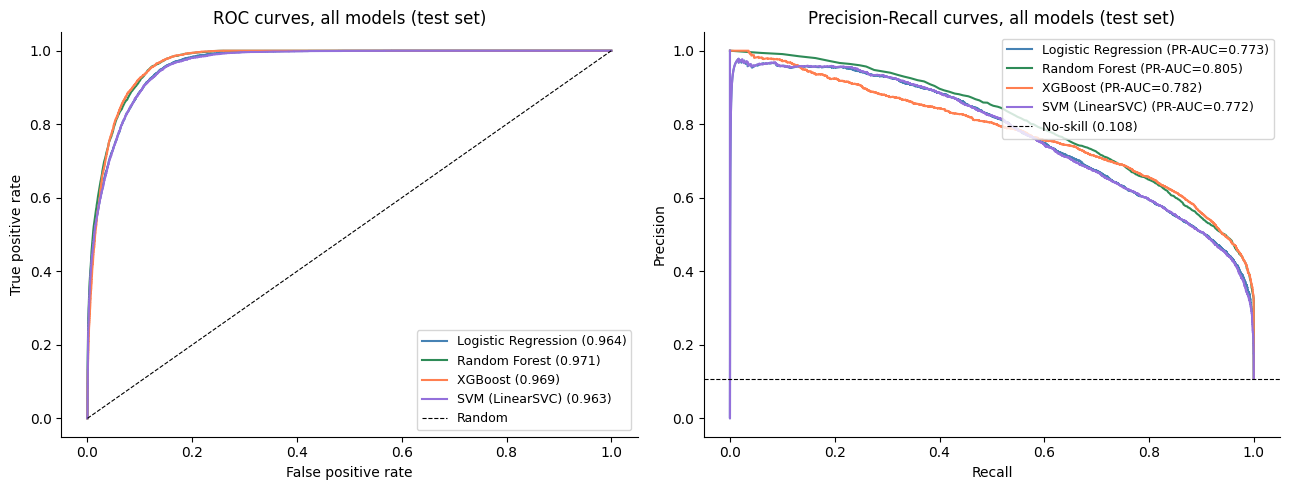

In [ ]:
model_data = [
    ('Logistic Regression', lr_probs,  lr_m['test_roc_auc'],  'steelblue'),
    ('Random Forest',       rf_probs,  rf_m['test_roc_auc'],  'seagreen'),
    ('XGBoost',             xgb_probs, xgb_m['test_roc_auc'], 'coral'),
    ('SVM (LinearSVC)',     svm_probs, svm_m['test_roc_auc'], 'mediumpurple'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
ax = axes[0]
for name, probs, auc, color in model_data:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, color=color, label=f'{name} ({auc:.3f})')
ax.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Random')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves, all models (test set)')
ax.legend(fontsize=9, loc='lower right')

# PR curves
ax = axes[1]
baseline = y_test.mean()
for name, probs, _, color in model_data:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    ax.plot(rec, prec, color=color, label=f'{name} (PR-AUC={pr_auc:.3f})')
ax.axhline(baseline, color='k', linestyle='--', linewidth=0.8, label=f'No-skill ({baseline:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curves, all models (test set)')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/all_models_roc_pr.png', bbox_inches='tight')
plt.show()

## 4. McNemar statistical significance tests

McNemar's test (McNemar, 1947) checks whether two classifiers make significantly different errors on the same test instances.  
The null hypothesis is that the two models have the same error rate. A p-value below 0.05 indicates a statistically significant difference in classification decisions.

In [ ]:
def run_mcnemar(name_a, preds_a, name_b, preds_b, y_true):
    """Build the 2x2 contingency table and run McNemar test."""
    b = ((preds_a != y_true) & (preds_b == y_true)).sum()  # A wrong, B right
    c = ((preds_a == y_true) & (preds_b != y_true)).sum()  # A right, B wrong
    table = [[0, b], [c, 0]]  # only off-diagonal matters
    result = mcnemar(table, exact=False, correction=True)
    print(f'{name_a} vs {name_b}: statistic={result.statistic:.4f}, p-value={result.pvalue:.4f}',
          '(significant)' if result.pvalue < 0.05 else '(not significant)')
    return result

print('McNemar tests (H0: identical error distribution):')
r1 = run_mcnemar('RF',  rf_preds,  'LR',  lr_preds,  y_test)
r2 = run_mcnemar('XGB', xgb_preds, 'LR',  lr_preds,  y_test)
r3 = run_mcnemar('XGB', xgb_preds, 'RF',  rf_preds,  y_test)
r4 = run_mcnemar('SVM', svm_preds, 'RF',  rf_preds,  y_test)

McNemar tests (H0: identical error distribution):
RF vs LR: statistic=1703.0025, p-value=0.0000 (significant)
XGB vs LR: statistic=1336.1782, p-value=0.0000 (significant)
XGB vs RF: statistic=185.9012, p-value=0.0000 (significant)
SVM vs RF: statistic=17.2841, p-value=0.0000 (significant)


## 5. Calibration curves

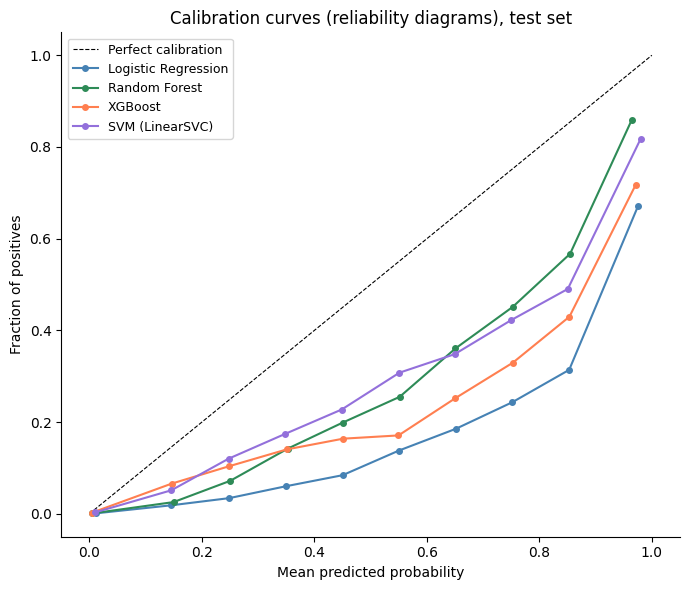

In [ ]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Perfect calibration')

for name, probs, _, color in model_data:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    ax.plot(mean_pred, frac_pos, marker='o', markersize=4, color=color, label=name)

ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration curves (reliability diagrams), test set')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/calibration_curves.png', bbox_inches='tight')
plt.show()

## 6. Final summary table and verdict

In [ ]:
print('=== FINAL RESULTS SUMMARY ===')
print(comparison_df.to_string(index=False))

best_auc_model = max(all_metrics, key=lambda m: m['test_roc_auc'])
best_f1_model  = max(all_metrics, key=lambda m: m['test_f1_macro'])

print(f'\nBest ROC-AUC: {best_auc_model["model"]} ({best_auc_model["test_roc_auc"]:.4f})')
print(f'Best F1-macro: {best_f1_model["model"]} ({best_f1_model["test_f1_macro"]:.4f})')

=== FINAL RESULTS SUMMARY ===
              Model       CV F1-macro        CV ROC-AUC Test F1-macro Test ROC-AUC Test PR-AUC
Logistic Regression 0.8899 +/- 0.0010 0.9776 +/- 0.0004        0.7666       0.9635      0.7729
      Random Forest 0.9175 +/- 0.0004 0.9858 +/- 0.0003        0.8262       0.9705      0.8051
            XGBoost 0.9111 +/- 0.0010 0.9873 +/- 0.0003        0.8151       0.9694      0.7815
    SVM (LinearSVC) 0.8973 +/- 0.0013 0.9775 +/- 0.0003        0.8151       0.9629      0.7721

Best ROC-AUC: Random Forest (0.9705)
Best F1-macro: Random Forest (0.8262)


## Conclusions

The comparison table and overlaid curves form the core of the report's Results section.  

Key points for the Discussion:
- McNemar tests indicate whether performance differences are statistically meaningful or within noise.
- The gap between CV scores (train distribution, 2020-2024) and test scores (2025-2026) quantifies temporal distribution shift.
- Calibration curves show which models can be trusted for probability-based policy decisions (e.g., ranking properties by retrofit likelihood).
- If XGBoost or RF calibration is poor, a Platt scaling wrapper (`CalibratedClassifierCV`) can be applied post-hoc.

**Limitations:**
- Sample size (200k train) is large but EPC data has known quality issues (Hardy and Glew, 2019): inconsistent string formats, imputed values in description fields, multiple certificates per property.
- The binary target ignores heterogeneity within the 'high potential' class.
- No spatial features (region used nominally only); geographical clustering may help a future model.

**Next:** `report/draft_report.docx`